In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

print("✓ Imports complete")

C:\Users\Mansoor\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✓ Imports complete


In [2]:
with open("../models/champion_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/tuning_metadata.json") as f:
    tuning_meta = json.load(f)

with open("../data/processed/featured/feature_metadata.json") as f:
    feature_meta = json.load(f)

FEATURES = feature_meta["final_features"]
TARGET   = feature_meta["target"]

df_train = pd.read_parquet("../data/processed/featured/train_featured.parquet", engine="fastparquet")
df_val   = pd.read_parquet("../data/processed/featured/val_featured.parquet",   engine="fastparquet")
df_test  = pd.read_parquet("../data/processed/featured/test_featured.parquet",  engine="fastparquet")

# Restore timestamps
ts_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for df in [df_train, df_val, df_test]:
    for col in ts_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

X_train = df_train[FEATURES]; y_train = df_train[TARGET]
X_val   = df_val[FEATURES];   y_val   = df_val[TARGET]
X_test  = df_test[FEATURES];  y_test  = df_test[TARGET]

print("✓ Champion model and data loaded")
print(f"  Champion      : {tuning_meta['champion']}")
print(f"  Val MAE       : {tuning_meta['champion_val_mae']:.4f}")
print(f"  X_train       : {X_train.shape}")
print(f"  X_val         : {X_val.shape}")
print(f"  X_test        : {X_test.shape}")

✓ Champion model and data loaded
  Champion      : xgboost_tuned
  Val MAE       : 4.6649
  X_train       : (67493, 44)
  X_val         : (14473, 44)
  X_test        : (14471, 44)


In [3]:
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    return {
        "mae": round(mae, 4), "rmse": round(rmse, 4),
        "r2": round(r2, 4),   "mape": round(mape, 4),
        "dir_acc": round(dir_acc, 4)
    }

train_pred = model.predict(X_train)
val_pred   = model.predict(X_val)
test_pred  = model.predict(X_test)

train_m = compute_metrics(y_train, train_pred)
val_m   = compute_metrics(y_val,   val_pred)
test_m  = compute_metrics(y_test,  test_pred)

print("FINAL MODEL EVALUATION — ALL SPLITS\n")
print(f"  {'Metric':<12} {'Train':>12} {'Val':>12} {'Test':>12}  {'Target':>10}")
print("  " + "-" * 60)

targets = {"mae": "< 5.0", "rmse": "< 8.0", "r2": "> 0.60", "mape": "reported", "dir_acc": "> 75%"}
for metric in ["mae", "rmse", "r2", "mape", "dir_acc"]:
    tv = train_m[metric]
    vv = val_m[metric]
    tev = test_m[metric]
    tgt = targets[metric]
    print(f"  {metric:<12} {tv:>12.4f} {vv:>12.4f} {tev:>12.4f}  {tgt:>10}")

print(f"\n  Overfit gap (Train - Test MAE) : {train_m['mae'] - test_m['mae']:.4f} days")
print(f"\n  SUCCESS CRITERIA CHECK:")
print(f"    MAE  < 5.0  : {'✓ PASS' if test_m['mae']  < 5.0  else '✗ FAIL'}  ({test_m['mae']:.4f})")
print(f"    RMSE < 8.0  : {'✓ PASS' if test_m['rmse'] < 8.0  else '✗ FAIL'}  ({test_m['rmse']:.4f})")
print(f"    R²   > 0.60 : {'✓ PASS' if test_m['r2']   > 0.60 else '✗ FAIL'}  ({test_m['r2']:.4f})")
print(f"    DirAcc > 75%: {'✓ PASS' if test_m['dir_acc'] > 75 else '✗ FAIL'}  ({test_m['dir_acc']:.2f}%)")

FINAL MODEL EVALUATION — ALL SPLITS

  Metric              Train          Val         Test      Target
  ------------------------------------------------------------
  mae                3.5347       4.6649       4.5816       < 5.0
  rmse               5.3829       8.0872       7.4144       < 8.0
  r2                 0.6893       0.4080       0.4328      > 0.60
  mape             263.1129     203.3787     162.1077    reported
  dir_acc           93.6571      91.4876      91.6730       > 75%

  Overfit gap (Train - Test MAE) : -1.0469 days

  SUCCESS CRITERIA CHECK:
    MAE  < 5.0  : ✓ PASS  (4.5816)
    RMSE < 8.0  : ✓ PASS  (7.4144)
    R²   > 0.60 : ✗ FAIL  (0.4328)
    DirAcc > 75%: ✓ PASS  (91.67%)


RESIDUAL ANALYSIS (test set)

  Mean residual      : -0.0439  (bias — ideally near 0)
  Std of residuals   : 7.4143
  Median residual    : -1.0617
  % over-predicted   : 60.22%  (predicted later than actual)
  % under-predicted  : 39.78%  (predicted earlier than actual)

  Residual percentiles:
      1th pct :   -13.974 days
      5th pct :    -8.448 days
     10th pct :    -6.354 days
     25th pct :    -3.657 days
     50th pct :    -1.062 days
     75th pct :     2.048 days
     90th pct :     7.041 days
     95th pct :    11.559 days
     99th pct :    26.062 days


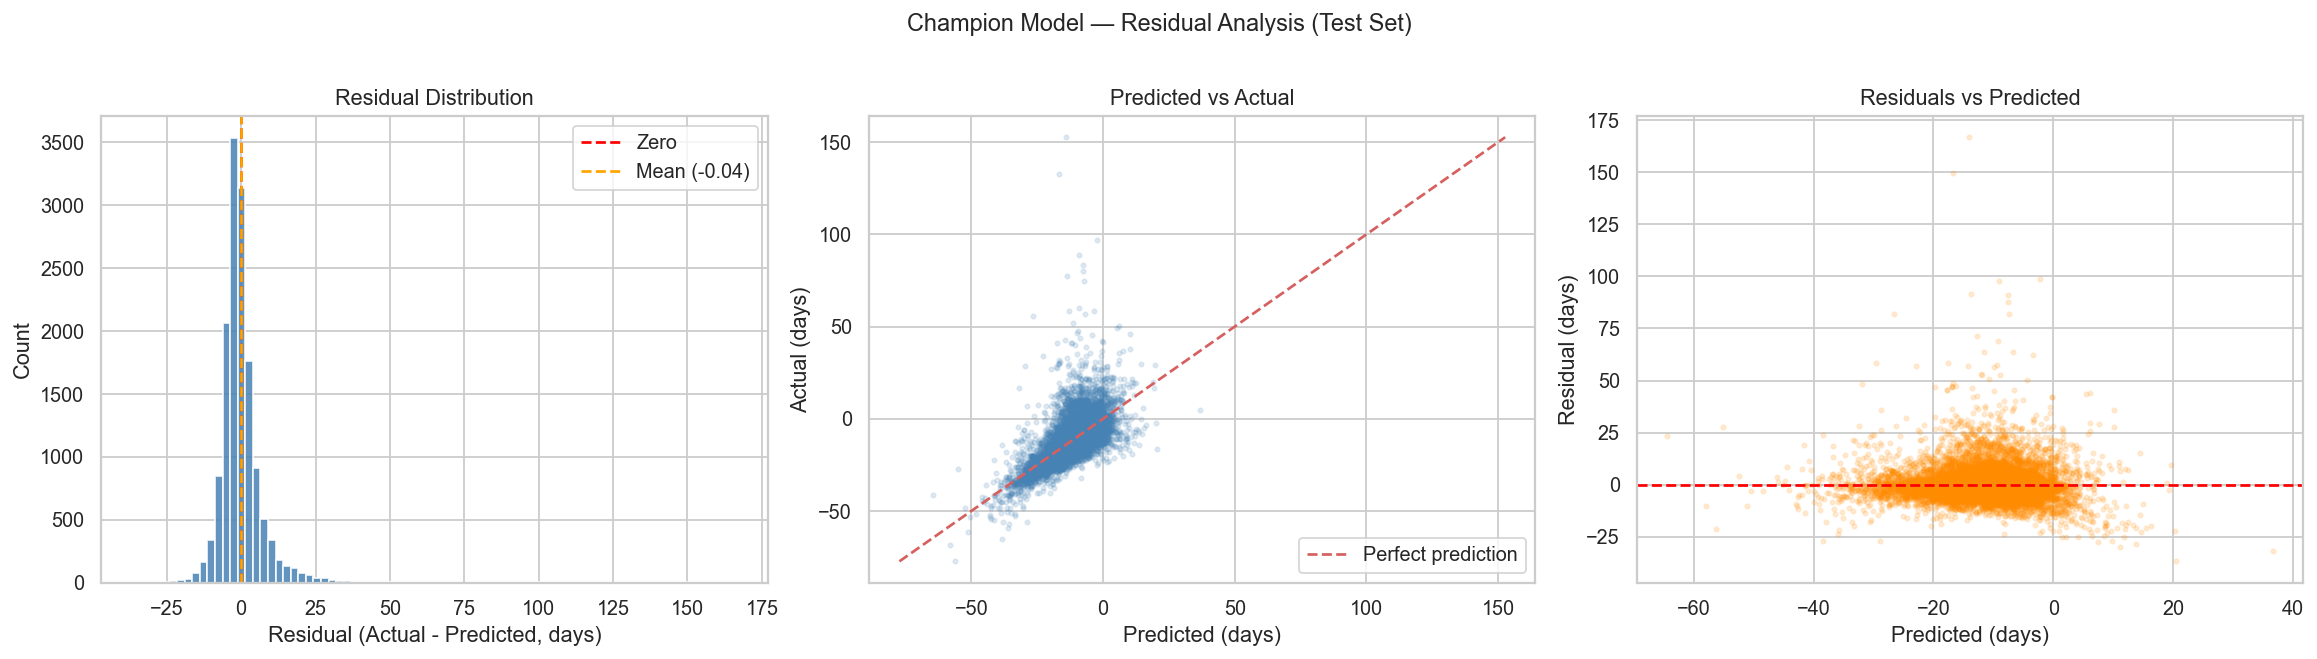

✓ Residual plots saved


In [4]:
residuals = y_test.values - test_pred

print("RESIDUAL ANALYSIS (test set)\n")
print(f"  Mean residual      : {residuals.mean():.4f}  (bias — ideally near 0)")
print(f"  Std of residuals   : {residuals.std():.4f}")
print(f"  Median residual    : {np.median(residuals):.4f}")
print(f"  % over-predicted   : {(residuals < 0).mean()*100:.2f}%  (predicted later than actual)")
print(f"  % under-predicted  : {(residuals > 0).mean()*100:.2f}%  (predicted earlier than actual)")

print(f"\n  Residual percentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"    {p:>3}th pct : {np.percentile(residuals, p):>9.3f} days")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Residual distribution
axes[0].hist(residuals, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero")
axes[0].axvline(residuals.mean(), color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean ({residuals.mean():.2f})")
axes[0].set_title("Residual Distribution", fontsize=12)
axes[0].set_xlabel("Residual (Actual - Predicted, days)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot 2 — Predicted vs Actual
axes[1].scatter(test_pred, y_test.values, alpha=0.15, s=6, color="steelblue")
lim_min = min(test_pred.min(), y_test.min())
lim_max = max(test_pred.max(), y_test.max())
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_title("Predicted vs Actual", fontsize=12)
axes[1].set_xlabel("Predicted (days)")
axes[1].set_ylabel("Actual (days)")
axes[1].legend()

# Plot 3 — Residuals vs Predicted
axes[2].scatter(test_pred, residuals, alpha=0.15, s=6, color="darkorange")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_title("Residuals vs Predicted", fontsize=12)
axes[2].set_xlabel("Predicted (days)")
axes[2].set_ylabel("Residual (days)")

plt.suptitle("Champion Model — Residual Analysis (Test Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/residual_analysis.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Residual plots saved")

In [5]:
# Does model performance degrade over time?
# Split test set into early vs late purchase months

df_test_copy = df_test.copy()
df_test_copy["pred"] = test_pred
df_test_copy["residual"] = y_test.values - test_pred
df_test_copy["abs_error"] = np.abs(df_test_copy["residual"])
df_test_copy["purchase_ym"] = df_test_copy["order_purchase_timestamp"].dt.to_period("M")

monthly_perf = df_test_copy.groupby("purchase_ym").agg(
    n_orders    = ("order_id", "count"),
    mae         = ("abs_error", "mean"),
    mean_resid  = ("residual", "mean"),
    r2_approx   = ("abs_error", lambda x: 1 - (x**2).sum() /
                   ((df_test_copy.loc[x.index, TARGET] - df_test_copy[TARGET].mean())**2).sum())
).reset_index()
monthly_perf["purchase_ym"] = monthly_perf["purchase_ym"].astype(str)

print("TEMPORAL STABILITY — MAE BY MONTH (test set)\n")
print(f"  {'Month':<12} {'Orders':>8} {'MAE':>8} {'Mean Resid':>12}")
print("  " + "-" * 46)
for _, row in monthly_perf.iterrows():
    flag = " ← spike" if row["mae"] > test_m["mae"] * 1.3 else ""
    print(f"  {row['purchase_ym']:<12} {int(row['n_orders']):>8} "
          f"{row['mae']:>8.3f} {row['mean_resid']:>12.3f}{flag}")

print(f"\n  Overall test MAE : {test_m['mae']:.4f}")
print(f"  Std of monthly MAE : {monthly_perf['mae'].std():.4f}")
print(f"  Max monthly MAE    : {monthly_perf['mae'].max():.4f}")
print(f"  Min monthly MAE    : {monthly_perf['mae'].min():.4f}")

TEMPORAL STABILITY — MAE BY MONTH (test set)

  Month          Orders      MAE   Mean Resid
  ----------------------------------------------
  2016-10            36    9.743       -1.399 ← spike
  2017-01           120    5.105       -0.400
  2017-02           242    5.915       -0.133
  2017-03           359    5.375       -0.391
  2017-04           318    5.427        1.766
  2017-05           491    4.009       -0.426
  2017-06           459    3.585        0.209
  2017-07           616    3.675        0.207
  2017-08           642    3.734       -0.154
  2017-09           653    3.991        0.068
  2017-10           659    4.323       -0.282
  2017-11          1066    5.586       -0.025
  2017-12           836    5.637        0.122
  2018-01          1054    5.130       -0.425
  2018-02           958    6.068       -0.134 ← spike
  2018-03          1065    6.265        0.071 ← spike
  2018-04          1049    4.587        0.167
  2018-05           996    4.371        0.372
  2018-

In [6]:
print("ERROR ANALYSIS BY CUSTOMER STATE (test set)\n")

state_errors = df_test_copy.groupby("customer_state").agg(
    n_orders    = ("order_id", "count"),
    mae         = ("abs_error", "mean"),
    mean_resid  = ("residual", "mean"),
    pct_late    = (TARGET, lambda x: (x > 0).mean() * 100),
).reset_index().sort_values("mae", ascending=False)

state_errors = state_errors[state_errors["n_orders"] >= 30]

print(f"  {'State':<8} {'Orders':>8} {'MAE':>8} {'Mean Resid':>12} {'% Late':>8}")
print("  " + "-" * 50)
for _, row in state_errors.iterrows():
    flag = " ←" if row["mae"] > test_m["mae"] * 1.2 else ""
    print(f"  {row['customer_state'].upper():<8} {int(row['n_orders']):>8} "
          f"{row['mae']:>8.3f} {row['mean_resid']:>12.3f} "
          f"{row['pct_late']:>7.2f}%{flag}")

ERROR ANALYSIS BY CUSTOMER STATE (test set)

  State      Orders      MAE   Mean Resid   % Late
  --------------------------------------------------
  AL             59    8.671        1.376   27.12% ←
  PA            147    8.073        0.196   10.88% ←
  PI             58    7.795        0.857   12.07% ←
  SE             45    7.460        3.736   24.44% ←
  RN             77    7.306        0.876   14.29% ←
  RO             41    7.182       -1.466    7.32% ←
  PB             78    6.761        1.995   10.26% ←
  PE            231    6.661       -0.081   10.82% ←
  CE            209    6.554        0.129   14.35% ←
  BA            437    6.530        0.618   14.87% ←
  RJ           1887    6.158        0.019   13.25% ←
  MA            122    5.781       -2.309   13.93% ←
  ES            316    5.634       -0.188   12.66% ←
  MT            140    5.396       -0.314    5.71%
  GO            290    5.372        0.945    9.66%
  RS            788    5.224        0.118    7.87%
  SC     

In [7]:
print("ERROR ANALYSIS BY PRODUCT CATEGORY (test set, categories ≥ 50 orders)\n")

cat_errors = df_test_copy.groupby("product_category_name_english").agg(
    n_orders    = ("order_id", "count"),
    mae         = ("abs_error", "mean"),
    mean_resid  = ("residual", "mean"),
    pct_late    = (TARGET, lambda x: (x > 0).mean() * 100),
).reset_index()

cat_errors = cat_errors[cat_errors["n_orders"] >= 50].sort_values("mae", ascending=False)

print(f"  TOP 15 WORST CATEGORIES (highest MAE):")
print(f"\n  {'Category':<45} {'Orders':>7} {'MAE':>7} {'% Late':>8}")
print("  " + "-" * 72)
for _, row in cat_errors.head(15).iterrows():
    print(f"  {str(row['product_category_name_english']):<45} "
          f"{int(row['n_orders']):>7} {row['mae']:>7.3f} "
          f"{row['pct_late']:>7.2f}%")

print(f"\n  TOP 10 BEST CATEGORIES (lowest MAE):")
print(f"\n  {'Category':<45} {'Orders':>7} {'MAE':>7} {'% Late':>8}")
print("  " + "-" * 72)
for _, row in cat_errors.tail(10).iterrows():
    print(f"  {str(row['product_category_name_english']):<45} "
          f"{int(row['n_orders']):>7} {row['mae']:>7.3f} "
          f"{row['pct_late']:>7.2f}%")

ERROR ANALYSIS BY PRODUCT CATEGORY (test set, categories ≥ 50 orders)

  TOP 15 WORST CATEGORIES (highest MAE):

  Category                                       Orders     MAE   % Late
  ------------------------------------------------------------------------
  furniture_living_room                              58   5.571   10.34%
  office_furniture                                  189   5.229    5.29%
  home_construction                                  78   5.122    6.41%
  furniture_decor                                   960   4.907    9.38%
  auto                                              548   4.901    9.49%
  garden_tools                                      457   4.815    8.97%
  baby                                              424   4.808    9.43%
  stationery                                        353   4.796    8.50%
  perfumery                                         443   4.756    8.35%
  pet_shop                                          267   4.713    8.61%
  sports_

In [8]:
print("ERROR ANALYSIS BY SELLER STATE (test set)\n")

seller_state_errors = df_test_copy.groupby("seller_state").agg(
    n_orders    = ("order_id", "count"),
    mae         = ("abs_error", "mean"),
    mean_resid  = ("residual", "mean"),
    pct_late    = (TARGET, lambda x: (x > 0).mean() * 100),
).reset_index().sort_values("mae", ascending=False)

seller_state_errors = seller_state_errors[seller_state_errors["n_orders"] >= 20]

print(f"  {'State':<8} {'Orders':>8} {'MAE':>8} {'Mean Resid':>12} {'% Late':>8}")
print("  " + "-" * 50)
for _, row in seller_state_errors.iterrows():
    flag = " ←" if row["mae"] > test_m["mae"] * 1.2 else ""
    print(f"  {row['seller_state'].upper():<8} {int(row['n_orders']):>8} "
          f"{row['mae']:>8.3f} {row['mean_resid']:>12.3f} "
          f"{row['pct_late']:>7.2f}%{flag}")

ERROR ANALYSIS BY SELLER STATE (test set)

  State      Orders      MAE   Mean Resid   % Late
  --------------------------------------------------
  CE             22    6.729       -0.049    9.09% ←
  ES             43    6.482        2.478   18.60% ←
  MG           1171    5.052        0.247    7.51%
  RJ            646    5.051       -0.229    9.60%
  SC            516    4.802       -0.592    6.01%
  DF            112    4.754       -0.363    4.46%
  PR           1059    4.599       -0.371    5.76%
  SP          10279    4.500        0.011    8.44%
  MA             49    4.465       -0.189   16.33%
  BA             99    4.275       -0.219    6.06%
  GO             77    4.274       -0.973    1.30%
  PE             73    4.152       -1.428    2.74%
  RS            280    3.747       -0.188    4.64%


In [9]:
print("ERROR ANALYSIS BY ESTIMATED DELIVERY WINDOW (test set)\n")

df_test_copy["delivery_window_bucket"] = pd.cut(
    df_test_copy["estimated_delivery_days"],
    bins=[0, 10, 15, 20, 25, 30, 40, 999],
    labels=["0-10d", "10-15d", "15-20d", "20-25d", "25-30d", "30-40d", "40d+"]
)

window_errors = df_test_copy.groupby("delivery_window_bucket", observed=True).agg(
    n_orders    = ("order_id", "count"),
    mae         = ("abs_error", "mean"),
    mean_resid  = ("residual", "mean"),
    pct_late    = (TARGET, lambda x: (x > 0).mean() * 100),
    avg_target  = (TARGET, "mean"),
).reset_index()

print(f"  {'Window':<10} {'Orders':>8} {'MAE':>8} {'Mean Resid':>12} "
      f"{'% Late':>8} {'Avg Variance':>14}")
print("  " + "-" * 66)
for _, row in window_errors.iterrows():
    print(f"  {str(row['delivery_window_bucket']):<10} {int(row['n_orders']):>8} "
          f"{row['mae']:>8.3f} {row['mean_resid']:>12.3f} "
          f"{row['pct_late']:>7.2f}% {row['avg_target']:>14.3f}")

print(f"\n  Key insight: Short windows (Olist gave little buffer) "
      f"likely correlate with higher late rates")

ERROR ANALYSIS BY ESTIMATED DELIVERY WINDOW (test set)

  Window       Orders      MAE   Mean Resid   % Late   Avg Variance
  ------------------------------------------------------------------
  0-10d           641    2.484        0.429   16.07%         -2.361
  10-15d         1530    2.516       -0.130    4.51%         -6.483
  15-20d         2460    3.763       -0.126    8.13%         -8.273
  20-25d         3971    4.614       -0.040    9.47%         -9.728
  25-30d         2883    5.041       -0.241    7.70%        -12.595
  30-40d         2388    6.064        0.303    7.41%        -16.320
  40d+            598    7.130       -0.449    2.01%        -27.912

  Key insight: Short windows (Olist gave little buffer) likely correlate with higher late rates


In [10]:
# Conformal prediction (split conformal) — distribution-free coverage guarantee
# Step 1: Compute calibration residuals on VAL set (already held out)
# Step 2: Find quantile of |residuals| at desired coverage level
# Step 3: Apply ± that quantile to test predictions

print("CONFORMAL PREDICTION INTERVALS\n")
print("  Method : Split Conformal Prediction")
print("  Calibration set : Validation split\n")

# Calibration residuals
cal_residuals = np.abs(y_val.values - val_pred)

# Target coverage levels
for coverage in [0.80, 0.90, 0.95]:
    alpha = 1 - coverage
    # Conformal quantile — adjusted for finite sample
    n_cal = len(cal_residuals)
    q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
    q_level = min(q_level, 1.0)
    conformal_q = np.quantile(cal_residuals, q_level)

    # Apply to test set
    lower = test_pred - conformal_q
    upper = test_pred + conformal_q

    # Empirical coverage on test set
    covered = np.mean((y_test.values >= lower) & (y_test.values <= upper))
    avg_width = np.mean(upper - lower)

    print(f"  Coverage target : {coverage*100:.0f}%")
    print(f"    Conformal quantile (half-width) : {conformal_q:.4f} days")
    print(f"    Interval width (avg)            : {avg_width:.4f} days  (± {conformal_q:.2f})")
    print(f"    Empirical coverage on test      : {covered*100:.2f}%")
    print()

# Save 90% intervals for use in deployment
alpha = 0.10
n_cal = len(cal_residuals)
q_level = min(np.ceil((n_cal + 1) * (1 - alpha)) / n_cal, 1.0)
conformal_q_90 = float(np.quantile(cal_residuals, q_level))

print(f"  → Deploying 90% interval: prediction ± {conformal_q_90:.2f} days")
print(f"  → This will be saved for use in the Streamlit app")

CONFORMAL PREDICTION INTERVALS

  Method : Split Conformal Prediction
  Calibration set : Validation split

  Coverage target : 80%
    Conformal quantile (half-width) : 6.6908 days
    Interval width (avg)            : 13.3816 days  (± 6.69)
    Empirical coverage on test      : 80.53%

  Coverage target : 90%
    Conformal quantile (half-width) : 9.8397 days
    Interval width (avg)            : 19.6795 days  (± 9.84)
    Empirical coverage on test      : 90.21%

  Coverage target : 95%
    Conformal quantile (half-width) : 13.6309 days
    Interval width (avg)            : 27.2618 days  (± 13.63)
    Empirical coverage on test      : 94.92%

  → Deploying 90% interval: prediction ± 9.84 days
  → This will be saved for use in the Streamlit app


In [11]:
print("EXAMPLE PREDICTIONS WITH CONFIDENCE INTERVALS (test set, first 15 rows)\n")
print(f"  {'#':<4} {'Actual':>9} {'Predicted':>11} {'Lower 90%':>11} "
      f"{'Upper 90%':>11} {'Covered':>9} {'Abs Error':>10}")
print("  " + "-" * 72)

sample_idx = df_test_copy.head(15).index
for i, idx in enumerate(sample_idx):
    actual    = y_test.loc[idx]
    pred      = test_pred[df_test.index.get_loc(idx)]
    lower     = pred - conformal_q_90
    upper     = pred + conformal_q_90
    covered   = "✓" if lower <= actual <= upper else "✗"
    abs_err   = abs(actual - pred)
    print(f"  {i+1:<4} {actual:>9.3f} {pred:>11.3f} {lower:>11.3f} "
          f"{upper:>11.3f} {covered:>9} {abs_err:>10.3f}")

EXAMPLE PREDICTIONS WITH CONFIDENCE INTERVALS (test set, first 15 rows)

  #       Actual   Predicted   Lower 90%   Upper 90%   Covered  Abs Error
  ------------------------------------------------------------------------
  1       -5.282      -3.057     -12.897       6.782         ✓      2.225
  2       -3.190      -5.989     -15.829       3.850         ✓      2.800
  3      -16.277     -15.853     -25.693      -6.013         ✓      0.424
  4       -7.115     -11.626     -21.465      -1.786         ✓      4.510
  5       -1.947      -7.127     -16.967       2.712         ✓      5.181
  6      -25.952     -12.910     -22.749      -3.070         ✗     13.043
  7      -36.090     -35.166     -45.005     -25.326         ✓      0.924
  8       -7.237      -6.493     -16.333       3.347         ✓      0.744
  9       -1.239      -9.957     -19.797      -0.117         ✓      8.718
  10     -14.152     -11.955     -21.795      -2.115         ✓      2.197
  11     -29.640     -21.092     -30.9

In [12]:
# Business layer: does the model correctly flag orders that will be late?
# late_flag = 1 if prediction > 0

print("LATE ORDER DETECTION (test set)\n")
print("  Rule: predict_late = 1 if model_prediction > 0\n")

actual_late   = (y_test.values > 0).astype(int)
predicted_late = (test_pred > 0).astype(int)

TP = ((actual_late == 1) & (predicted_late == 1)).sum()
TN = ((actual_late == 0) & (predicted_late == 0)).sum()
FP = ((actual_late == 0) & (predicted_late == 1)).sum()
FN = ((actual_late == 1) & (predicted_late == 0)).sum()

precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy   = (TP + TN) / len(actual_late)

print(f"  Confusion Matrix:")
print(f"    {'':>20} {'Pred: Not Late':>16} {'Pred: Late':>12}")
print(f"    {'Actual: Not Late':<20} {TN:>16,} {FP:>12,}")
print(f"    {'Actual: Late':<20} {FN:>16,} {TP:>12,}")

print(f"\n  Metrics:")
print(f"    Precision (late class) : {precision:.4f}")
print(f"    Recall (late class)    : {recall:.4f}")
print(f"    F1-Score (late class)  : {f1:.4f}")
print(f"    Overall Accuracy       : {accuracy:.4f}")

print(f"\n  Late orders in test  : {actual_late.sum():,} ({actual_late.mean()*100:.2f}%)")
print(f"  Late orders flagged  : {predicted_late.sum():,}")
print(f"  Correctly flagged    : {TP:,} / {actual_late.sum():,} ({recall*100:.1f}% recall)")
print(f"  False alarms         : {FP:,} ({FP/(FP+TN)*100:.1f}% of non-late orders)")

LATE ORDER DETECTION (test set)

  Rule: predict_late = 1 if model_prediction > 0

  Confusion Matrix:
                           Pred: Not Late   Pred: Late
    Actual: Not Late               13,069          243
    Actual: Late                      962          197

  Metrics:
    Precision (late class) : 0.4477
    Recall (late class)    : 0.1700
    F1-Score (late class)  : 0.2464
    Overall Accuracy       : 0.9167

  Late orders in test  : 1,159 (8.01%)
  Late orders flagged  : 440
  Correctly flagged    : 197 / 1,159 (17.0% recall)
  False alarms         : 243 (1.8% of non-late orders)


# Running this for 2nd layer of classification use it in 2nd phase of project

In [13]:
# import json

# validation_results = {
#     "champion_model"        : tuning_meta["champion"],
#     "train_metrics"         : train_m,
#     "val_metrics"           : val_m,
#     "test_metrics"          : test_m,
#     "conformal_q_90"        : conformal_q_90,
#     "late_detection": {
#         "precision"         : round(precision, 4),
#         "recall"            : round(recall, 4),
#         "f1"                : round(f1, 4),
#         "accuracy"          : round(accuracy, 4),
#         "tp": int(TP), "tn": int(TN),
#         "fp": int(FP), "fn": int(FN),
#     },
#     "success_criteria": {
#         "mae_pass"      : bool(test_m["mae"]     < 5.0),
#         "rmse_pass"     : bool(test_m["rmse"]    < 8.0),
#         "r2_pass"       : bool(test_m["r2"]      > 0.60),
#         "dir_acc_pass"  : bool(test_m["dir_acc"] > 75.0),
#     }
# }

# os.makedirs("../models", exist_ok=True)
# with open("../models/validation_results.json", "w") as f:
#     json.dump(validation_results, f, indent=2)

# print("✓ Validation results saved to models/validation_results.json")
# print(f"\n  PHASE 10 SUMMARY")
# print(f"  {'─'*50}")
# print(f"  Champion model     : {tuning_meta['champion']}")
# print(f"  Test MAE           : {test_m['mae']:.4f} days")
# print(f"  Test RMSE          : {test_m['rmse']:.4f} days")
# print(f"  Test R²            : {test_m['r2']:.4f}")
# print(f"  Directional Acc    : {test_m['dir_acc']:.2f}%")
# print(f"  90% interval width : ± {conformal_q_90:.2f} days")
# print(f"  Late recall        : {recall*100:.1f}%")
# print(f"  Late F1            : {f1:.4f}")
# print(f"\n  SUCCESS CRITERIA:")
# for k, v in validation_results["success_criteria"].items():
#     print(f"    {k:<15} : {'✓ PASS' if v else '✗ FAIL'}")

✓ Validation results saved to models/validation_results.json

  PHASE 10 SUMMARY
  ──────────────────────────────────────────────────
  Champion model     : xgboost_tuned
  Test MAE           : 4.5816 days
  Test RMSE          : 7.4144 days
  Test R²            : 0.4328
  Directional Acc    : 91.67%
  90% interval width : ± 9.84 days
  Late recall        : 17.0%
  Late F1            : 0.2464

  SUCCESS CRITERIA:
    mae_pass        : ✓ PASS
    rmse_pass       : ✓ PASS
    r2_pass         : ✗ FAIL
    dir_acc_pass    : ✓ PASS
